<a href="https://colab.research.google.com/github/soleildayana/Celestial-Mechanics/blob/main/TrompoHamiltoniano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación de trompo siguiendo el formalismo hamiltoniano y sus ecuaciones de movimiento

Soleil Dayana Niño Murcia

Mecánica Celeste 2026-1

### 1. Importación de Librerías
Utilizaremos `numpy` para el cálculo numérico, `scipy.integrate` para resolver las ecuaciones diferenciales y `matplotlib` para la visualización 3D.

In [23]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

### 2. Definición del Modelo Hamiltoniano
Implementamos las ecuaciones de Hamilton. Como $p_\phi$ y $p_\psi$ son constantes de movimiento, simplificamos el sistema a 4 variables dinámicas: $(\theta, \phi, \psi, p_\theta)$.

### Resumen de Ecuaciones del Sistema

El sistema se describe mediante el **Hamiltoniano**:

$$H = \frac{p_\theta^2}{2 I_1} + \frac{(p_\phi - p_\psi \cos \theta)^2}{2 I_1 \sin^2 \theta} + \frac{p_\psi^2}{2 I_3} + mgl \cos \theta$$

Las **Ecuaciones Canónicas de Hamilton** que estamos integrando son:

1.  **Ecuaciones para las coordenadas ($q$):**
    $$\dot{\theta} = \frac{\partial H}{\partial p_\theta} = \frac{p_\theta}{I_1}$$
    $$\dot{\phi} = \frac{\partial H}{\partial p_\phi} = \frac{p_\phi - p_\psi \cos \theta}{I_1 \sin^2 \theta}$$
    $$\dot{\psi} = \frac{\partial H}{\partial p_\psi} = \frac{p_\psi}{I_3} - \frac{\cos \theta (p_\phi - p_\psi \cos \theta)}{I_1 \sin^2 \theta}$$

2.  **Ecuación para el momento conjugado ($p$):**
    $\dot{p}_\theta = -\frac{\partial H}{\partial \theta} = \frac{(p_\phi -
    p_\psi \cos \theta)(p_\psi \sin^2 \theta - (p_\phi - p_\psi \cos \theta) \cos \theta)}{I_1 \sin^3 \theta} + mgl \sin \theta$


*Nota: $p_\phi$ y $p_\psi$ son constantes de movimiento debido a las simetrías cíclicas.*

In [24]:
def spinning_top_hamiltonian(t, y, I1, I3, m, g, l, p_phi, p_psi):
    theta, phi, psi, p_theta = y

    # Evitar singularidad en sin(theta) = 0
    sin_theta = np.sin(theta)
    if abs(sin_theta) < 1e-6: sin_theta = 1e-6
    cos_theta = np.cos(theta)

    # Ecuaciones de Hamilton (q_dot = dH/dp, p_dot = -dH/dq)
    d_theta = p_theta / I1
    d_phi = (p_phi - p_psi * cos_theta) / (I1 * sin_theta**2)
    d_psi = (p_psi / I3) - (cos_theta * (p_phi - p_psi * cos_theta)) / (I1 * sin_theta**2)

    # p_theta_dot = -dH/d_theta
    term1 = (p_phi - p_psi * cos_theta) * (p_psi * sin_theta**2 - (p_phi - p_psi * cos_theta) * cos_theta) / (I1 * sin_theta**3)
    d_p_theta = -term1 + m * g * l * sin_theta

    return [d_theta, d_phi, d_psi, d_p_theta]

### 3. Configuración y Simulación
Definimos los parámetros físicos y las condiciones iniciales para observar la precesión y nutación.

In [25]:
# Parámetros físicos
m, g, l = 1.0, 9.81, 0.5
I1, I3 = 0.5, 0.2

# Condiciones iniciales
theta0 = np.deg2rad(30)  # 30 grados de inclinación
phi0, psi0 = 0.0, 0.0
dot_psi = 50.0           # Rotación propia rápida (rad/s)
dot_phi = 2.0            # Precesión inicial
dot_theta = 0.5          # Empujón inicial para ver nutación

# Cálculo de momentos conjugados iniciales (conservados)
p_psi = I3 * (dot_psi + dot_phi * np.cos(theta0))
p_phi = I1 * dot_phi * np.sin(theta0)**2 + p_psi * np.cos(theta0)
p_theta = I1 * dot_theta

y0 = [theta0, phi0, psi0, p_theta]
t_span = (0, 10)
t_eval = np.linspace(0, 10, 1000)

sol = solve_ivp(spinning_top_hamiltonian, t_span, y0, t_eval=t_eval, args=(I1, I3, m, g, l, p_phi, p_psi))

### 4. Visualización 3D de la Trayectoria
Convertimos los ángulos de Euler a coordenadas cartesianas para ver el camino que recorre el eje del trompo.

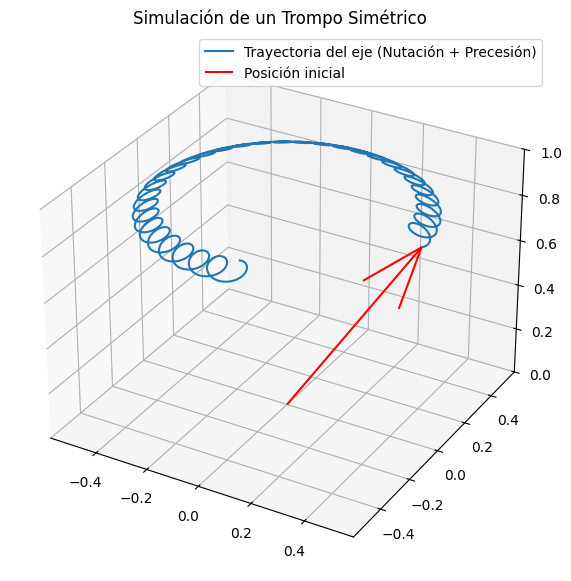

In [26]:
theta_vec = sol.y[0]
phi_vec = sol.y[1]

# Coordenadas del extremo del eje (l=1 para normalizar la visualización)
x = np.sin(theta_vec) * np.cos(phi_vec)
y = np.sin(theta_vec) * np.sin(phi_vec)
z = np.cos(theta_vec)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, label='Trayectoria del eje (Nutación + Precesión)')
ax.quiver(0, 0, 0, x[0], y[0], z[0], color='r', label='Posición inicial')
ax.set_zlim(0, 1)
ax.set_title("Simulación de un Trompo Simétrico")
ax.legend()
plt.show()

### 5. Animación Interactiva con Plotly
Creamos una animación donde se muestra el cuerpo del trompo (barra negra) y su trayectoria (azul con transparencia).

In [27]:
# Ajustamos el paso para mantener suficiente detalle pero mejorar el rendimiento
step = 4
t_anim = t_eval[::step]
x_anim, y_anim, z_anim = x[::step], y[::step], z[::step]

# Crear la figura base
fig = go.Figure(
    data=[
        # Trayectoria (estela)
        go.Scatter3d(x=x_anim, y=y_anim, z=z_anim,
                     mode='lines',
                     line=dict(color='cyan', width=2),
                     opacity=0.4,
                     name='Trayectoria'),
        # Cuerpo del trompo (Barra)
        go.Scatter3d(x=[0, x_anim[0]], y=[0, y_anim[0]], z=[0, z_anim[0]],
                     mode='lines+markers',
                     line=dict(color='red', width=8),
                     marker=dict(size=[0, 25], color='red'),
                     name='Cuerpo del Trompo')
    ],
    layout=go.Layout(
        template="plotly_dark",
        scene=dict(
            xaxis=dict(range=[-0.8, 0.8], backgroundcolor="black"),
            yaxis=dict(range=[-0.8, 0.8], backgroundcolor="black"),
            zaxis=dict(range=[0, 1], backgroundcolor="black"),
            aspectmode='cube'
        ),
        updatemenus=[dict(type='buttons', buttons=[dict(
            label='Simular en vivo',
            method='animate',
            args=[None, {"frame": {"duration": 20, "redraw": True}, "fromcurrent": True, "transition": {"duration": 0}}]
        )])]
    ),
    frames=[go.Frame(
        data=[go.Scatter3d(x=x_anim[:i], y=y_anim[:i], z=z_anim[:i]),
              go.Scatter3d(x=[0, x_anim[i]], y=[0, y_anim[i]], z=[0, z_anim[i]])]
    ) for i in range(1, len(t_anim))]
)

fig.show()